In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
plt.style.use('ggplot')
%matplotlib inline

### Пункты 1-2

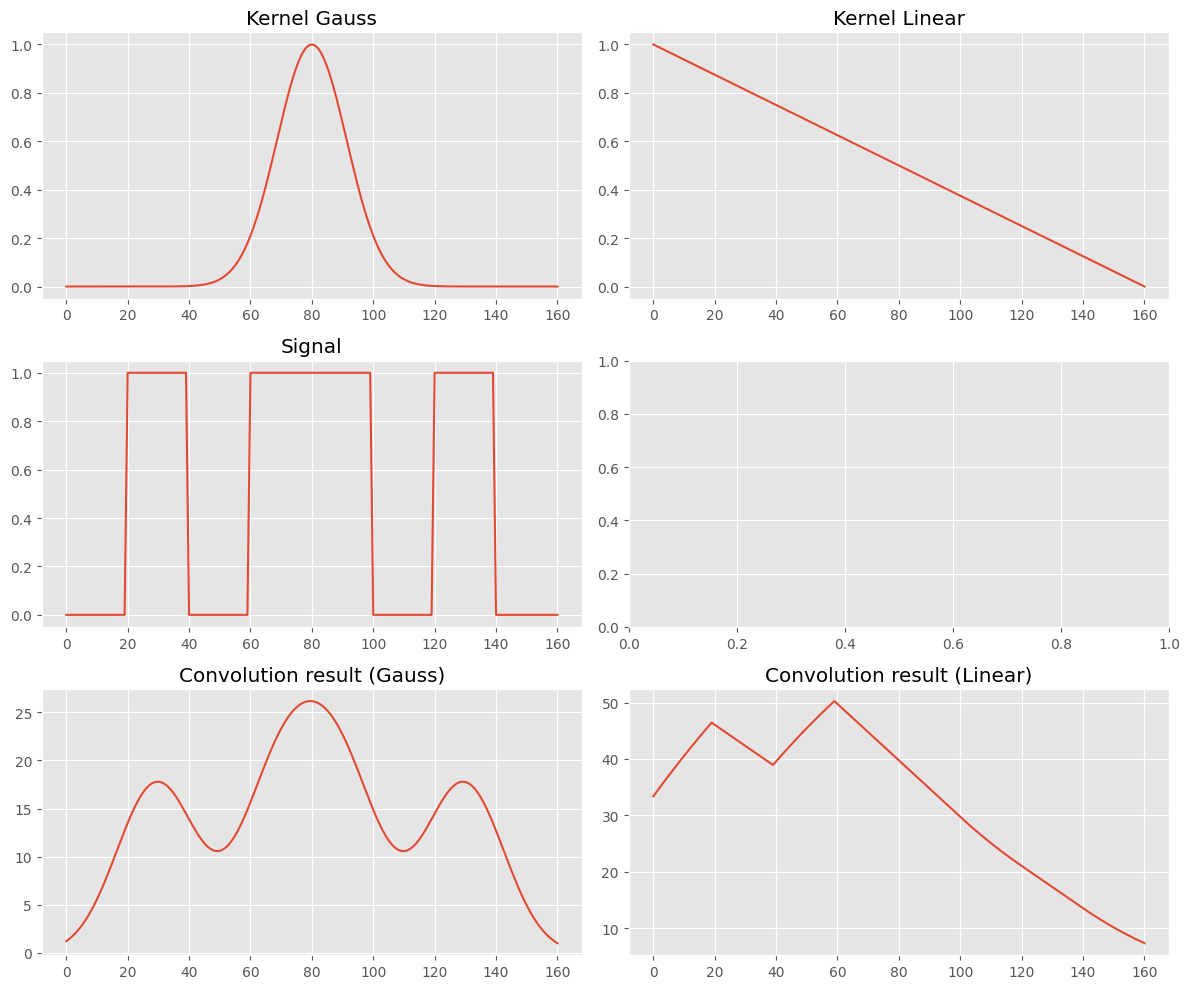

In [3]:
N = 161
t = np.arange(N)

signal = np.zeros(N)
signal[20:40] = 1
signal[60:100] = 1
signal[120:140] = 1

# Ядро Гаусс
x = np.linspace(-5, 5, N)
kernel_gauss = np.exp(-x**2)

# Ядро линейное 
kernel_linear = np.linspace(1, 0, N)

conv_gauss_np = np.convolve(signal, kernel_gauss, mode='same')
conv_linear_np = np.convolve(signal, kernel_linear, mode='same') #mode = 'full'

def my_convolve(sig, kern):
    sig_pad = np.pad(sig, (len(kern)//2, len(kern)//2), mode='constant')
    result = np.zeros_like(sig)
    for i in range(len(sig)):
        result[i] = np.sum(sig_pad[i:i+len(kern)] * kern)
    return result

conv_gauss_my = my_convolve(signal, kernel_gauss)
conv_linear_my = my_convolve(signal, kernel_linear)

t_full = np.arange(len(conv_linear_np))

fig, axs = plt.subplots(3, 2, figsize=(12, 10))
axs[0,0].plot(t, kernel_gauss); axs[0,0].set_title('Kernel Gauss')
axs[1,0].plot(t, signal); axs[0,1].set_title('Kernel Linear')
axs[0,1].plot(t, kernel_linear); axs[1,0].set_title('Signal')
axs[2,0].plot(t, conv_gauss_np); axs[2,0].set_title('Convolution result (Gauss)')
axs[2,1].plot(t, conv_linear_np); axs[2,1].set_title('Convolution result (Linear)')

# axs[2,1].plot(t_full, conv_linear_np)
# axs[2,1].set_title('Convolution result (Linear, full)')

plt.tight_layout()
plt.show()

### Пункт 3

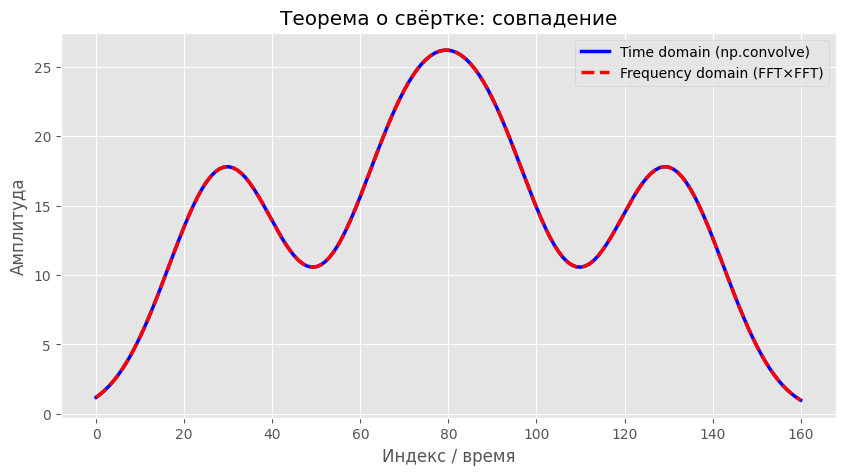

In [ ]:
conv_time = np.convolve(signal, kernel_gauss, mode='same')

def fft_convolve_same(sig, kern):
    N = len(sig)
    M = len(kern)
    padded_len = N + M - 1                    
    
    sig_pad = np.pad(sig, (0, padded_len - N), mode='constant')
    kern_pad = np.pad(kern, (0, padded_len - M), mode='constant')
    
    S = fft(sig_pad)
    K = fft(kern_pad)
    conv_full = ifft(S * K).real             
    
    start = (M - 1) // 2
    return conv_full[start : start + N]

conv_freq = fft_convolve_same(signal, kernel_gauss)

plt.figure(figsize=(10, 5))
plt.plot(t, conv_time, 'b-', linewidth=2.5, label='Time domain (np.convolve)')
plt.plot(t, conv_freq, 'r--', linewidth=2.5, label='Frequency domain (FFT×FFT)')
plt.title('Теорема о свёртке: совпадение')
plt.xlabel('Индекс / время')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()
plt.show()


### Пункты 4-5

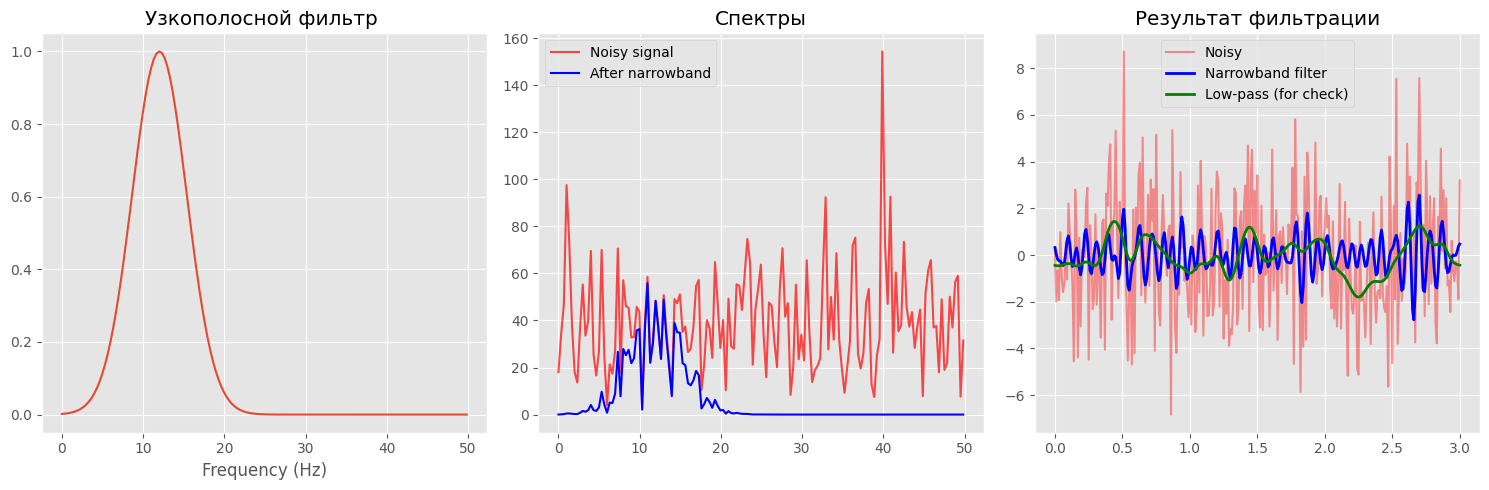

In [16]:
import numpy as np
from scipy.fft import fft, ifft, fftfreq
import matplotlib.pyplot as plt

fs = 100.0
T = 3.0
N = 301
t = np.linspace(0, T, N)
freq = fftfreq(N, 1/fs)[:N//2 + 1]

# Сигнал + шум
signal_clean = np.sin(2*np.pi*40*t) + 0.5*np.sin(2*np.pi*3*t)
noise = 2.5 * np.random.randn(N)
signal_noisy = signal_clean + noise

p = 0.0
w = 8.0
s = w * (2*np.pi - 1) / (4*np.pi)        

# Узкополосный фильтр
p_narrow = 12.0
G_narrow = np.exp(-0.5 * ((freq - p_narrow)/s)**2)

# Фильтр нижних частот
G_lowpass = np.exp(-0.5 * ((freq - p)/s)**2)   # p=0

def to_full_freq_response(H_pos):
    return np.concatenate((H_pos, H_pos[1:][::-1]))


S_noisy = fft(signal_noisy)

S_narrow = S_noisy * to_full_freq_response(G_narrow)
filtered_narrow = ifft(S_narrow).real

S_lowpass = S_noisy * to_full_freq_response(G_lowpass)
filtered_lowpass = ifft(S_lowpass).real


kernel_time = np.exp(-((t - t.mean()) / (T/6))**2)  
conv_time = np.convolve(signal_noisy, kernel_time, mode='same')

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(freq, G_narrow)
axs[0].set_title('Узкополосной фильтр ')
axs[0].set_xlabel('Frequency (Hz)')

axs[1].plot(freq, np.abs(S_noisy[:N//2+1]), 'r', alpha=0.7, label='Noisy signal')
axs[1].plot(freq, np.abs(S_narrow[:N//2+1]), 'b', label='After narrowband')
axs[1].set_title('Спектры')
axs[1].legend()

axs[2].plot(t, signal_noisy, 'r', alpha=0.4, label='Noisy')
axs[2].plot(t, filtered_narrow, 'b', linewidth=2, label='Narrowband filter')
axs[2].plot(t, filtered_lowpass, 'g', linewidth=2, label='Low-pass (for check)')
axs[2].set_title('Результат фильтрации')
axs[2].legend()

plt.tight_layout()
plt.show()

### Пункт 6

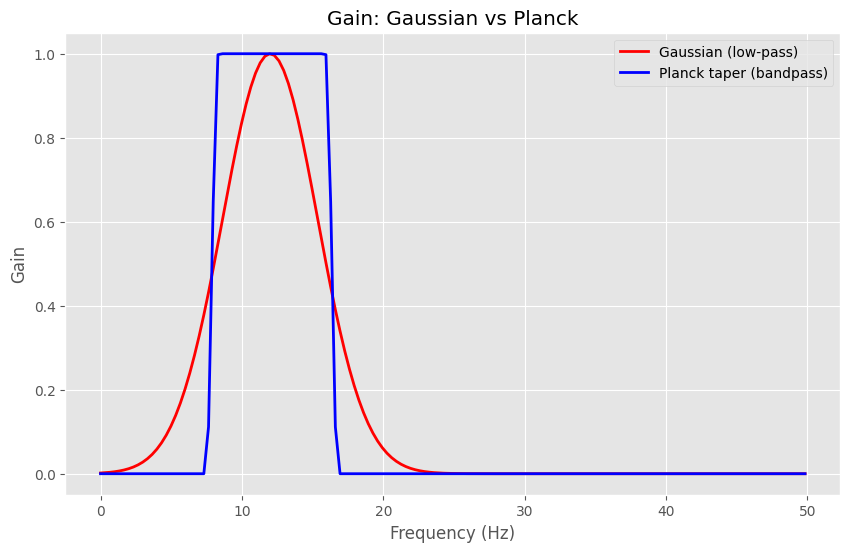

In [ ]:
def planck_taper_window(M, epsilon=0.2):
    
    a = np.zeros(M)
    if M <= 1 or not (0 < epsilon <= 0.5):
        return a
    eps_Nm1 = epsilon * (M - 1)
    for k in range(1, M-1):
        if k < eps_Nm1:
            za = eps_Nm1 * (1/k + 1/(k - eps_Nm1))
            a[k] = 1 / (np.exp(za) + 1)
        elif k <= (1 - epsilon) * (M - 1):
            a[k] = 1.0
        else:
            zb = eps_Nm1 * (1/(M-1-k) + 1/((1-epsilon)*(M-1) - k))
            a[k] = 1 / (np.exp(zb) + 1)
    return a

def planck_bandpass(freq, center_freq, bandwidth, epsilon=0.1, fs=100.0):
    M = len(freq)
    H = np.zeros(M)
    
    df = freq[1] - freq[0]                    
    half_bw = bandwidth / 2
    
    idx_start = np.searchsorted(freq, center_freq - half_bw)
    idx_end   = np.searchsorted(freq, center_freq + half_bw)
    
    window_len = idx_end - idx_start
    if window_len < 10:
        window_len = 10  
    
    taper = planck_taper_window(window_len, epsilon=epsilon)
    
    H[idx_start:idx_start + window_len] = taper
    
    return H 

center_freq = 12.0     
bandwidth   = 10.0       
epsilon     = 0.12      

H_planck = planck_bandpass(freq, center_freq, bandwidth, epsilon=epsilon)

# Фильтрация
S_filtered_planck = S_noisy * to_full_freq_response(H_planck)
filtered_planck = ifft(S_filtered_planck).real

plt.figure(figsize=(10, 6))
plt.plot(freq, G_narrow, 'r-', linewidth=2, label='Gaussian (low-pass)')
plt.plot(freq, H_planck,   'b-', linewidth=2, label='Planck taper (bandpass)')
plt.title('Gain: Gaussian vs Planck')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain')
plt.grid(True)
plt.legend()
plt.show()

### Пункт 7

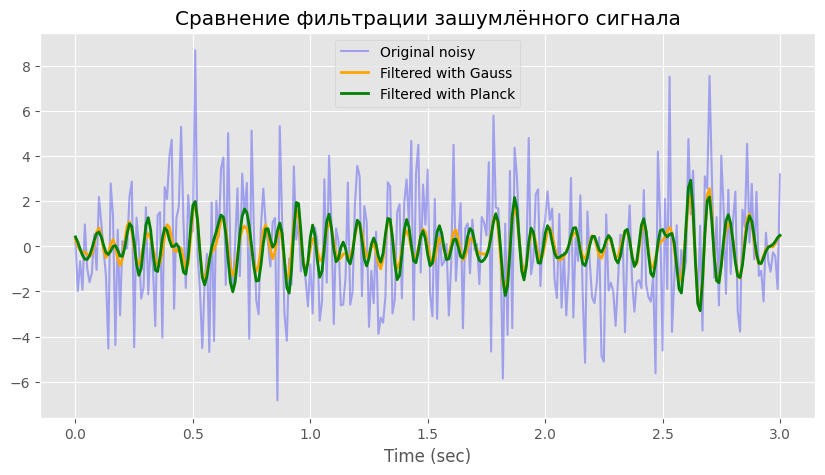

: 

In [ ]:

plt.figure(figsize=(10, 5))
plt.plot(t, signal_noisy, 'b-', alpha=0.3, label='Original noisy')
plt.plot(t, filtered_narrow, 'orange', linewidth=2, label='Filtered with Gauss')
plt.plot(t, filtered_planck, 'green', linewidth=2, label='Filtered with Planck')
plt.title('Сравнение фильтрации зашумлённого сигнала')
plt.xlabel('Time (sec)')
plt.legend()
plt.show()